In [665]:
%load_ext autoreload
%autoreload 2


import pandas as pd
import torch
from torch.utils.data import DataLoader
from dataset import CustomDataset
from dnn_model import DnnWOTransformer
import torch.nn as nn

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [666]:
# from sklearn.metrics import ndcg_score
from sklearn.metrics import f1_score
import scipy.stats as stats
import numpy as np

In [667]:
csv_path = "tables\\trkeDID_pits_over2.csv"  # replace with your actual file path
all_data = pd.read_csv(csv_path)
all_data = all_data.fillna(-1)

In [668]:
#all_data = all_data[all_data['season'] > 2018]

In [669]:
# prebacivanje u 5 karegorija
def pos_to_class(pos):
    if pos < 5:
        return 0
    elif pos < 9:
        return 1
    elif pos < 13:
        return 2
    elif pos < 17:
        return 3
    else:
        return 4
    
    

In [670]:
all_data['class'] = all_data['position_race'].apply(pos_to_class)

In [671]:
all_data.head()

,season,round,drivers_num,position_quali,position_race,status,driver,constructor,grid,laps,...,avg_gained_lost_last5,num_overtakes,avg_pos_last5,avg_pit_duration_last5,best_qual_time,avg_pit_duration_prev_race,avg_pit_duration_prev_driver_race,avg_overtakes_prev_season_per_circuit,best_qual_time_ms,class
0,2018,1,14,11,5,Finished,Alonso,McLaren,10,58,...,-1.0,6.0,-1.0,-1.0,1:23.692,-1.0,-1.0,-1.0,83692.0,1
1,2018,1,77,10,8,Finished,Bottas,Mercedes,15,58,...,-1.0,6.0,-1.0,-1.0,1:22.089,-1.0,-1.0,-1.0,82089.0,1
2,2018,1,28,16,15,+1 Lap,Hartley,Toro Rosso,16,57,...,-1.0,5.0,-1.0,-1.0,-1,-1.0,-1.0,-1.0,-1.0,3
3,2018,1,9,17,19,Steering,Ericsson,Sauber,17,5,...,-1.0,-1.0,-1.0,-1.0,1:24.556,-1.0,-1.0,-1.0,84556.0,4
4,2018,1,10,20,18,Engine,Gasly,Toro Rosso,20,13,...,-1.0,1.0,-1.0,-1.0,1:25.295,-1.0,-1.0,-1.0,85295.0,4


In [672]:
all_data.columns = all_data.columns.str.strip()
categorical_cols = ['constructor', 'driverId', 'race_name',
                                'circuit']

numerical_cols = ['season', 'round', 'position_quali', 'grid', 
                  
                  'number_of_laps', 'number_of_corners', 'lap_length', 
                  'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 
                  'WindSpeed', 'rain_bin', 'wind_direction', 
                  'last_year_time', 'avg_position_last5', 
                  'num_dnfs_last5', 'avg_gained_lost_last5', 
                  'avg_pos_last5', 'avg_pit_duration_last5',
                  'avg_pit_duration_prev_race','avg_pit_duration_prev_driver_race', 
                  'avg_overtakes_prev_season_per_circuit', 'best_qual_time_ms']

In [673]:
target_col = 'class'
for col in categorical_cols:
    if all_data[col].dtype == 'object':  # ako je string tip
        all_data[col], uniques = pd.factorize(all_data[col])
        print(f"Kolona '{col}' kodirana u int. Broj unikatnih vrednosti: {len(uniques)}")

Kolona 'constructor' kodirana u int. Broj unikatnih vrednosti: 16
Kolona 'driverId' kodirana u int. Broj unikatnih vrednosti: 40
Kolona 'race_name' kodirana u int. Broj unikatnih vrednosti: 36
Kolona 'circuit' kodirana u int. Broj unikatnih vrednosti: 31


In [674]:
batch_size = 4

In [675]:
embedding_dim = 8
num_numerical = len(numerical_cols)

In [676]:
dataset = CustomDataset(all_data, target_col, numerical_cols, categorical_cols)

# Create a dataloader with batch size 1 (one race at a time)
loader_test = DataLoader(dataset, batch_size, shuffle=False)

In [677]:
embeddings_dict = {
    col: dataset.num_of_cat_features[col]
    for col in categorical_cols
}

In [678]:
hidden_dim = 512
dropout = 0.5
lr = 0.001

In [679]:
class ListNetLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred_scores, target_ranks):
        # Convert ranks to relevance (higher = better)
        max_rank = target_ranks.max(dim=1, keepdim=True)[0]
        relevance = max_rank - target_ranks + 1  # shape: [B, N]

        # Compute probability distributions
        true_prob = torch.softmax(relevance, dim=1)
        pred_log_prob = torch.log_softmax(pred_scores, dim=1)

        # Cross entropy between predicted and true distributions
        loss = -torch.sum(true_prob * pred_log_prob, dim=1).mean()
        return loss


In [680]:
class LambdaRank(nn.Module):
    def __init__(self, net_structures, leaky_relu=False, sigma=1.0, double_precision=False):
        """Fully Connected Layers with Sigmoid activation at the last layer

        :param net_structures: list of int for LambdaRank FC width
        """
        super(LambdaRank, self).__init__()
        self.fc_layers = len(net_structures)
        for i in range(len(net_structures) - 1):
            setattr(self, 'fc' + str(i + 1), nn.Linear(net_structures[i], net_structures[i+1]))
            if leaky_relu:
                setattr(self, 'act' + str(i + 1), nn.LeakyReLU())
            else:
                setattr(self, 'act' + str(i + 1), nn.ReLU())
        setattr(self, 'fc' + str(len(net_structures)), nn.Linear(net_structures[-1], 1))
        if double_precision:
            for i in range(1, len(net_structures) + 1):
                setattr(self, 'fc' + str(i), getattr(self, 'fc' + str(i)).double())
        self.sigma = sigma
        # self.activation = nn.Sigmoid()
        self.activation = nn.ReLU6()

    def forward(self, input1):
        # from 1 to N - 1 layer, use ReLU as activation function
        for i in range(1, self.fc_layers):
            fc = getattr(self, 'fc' + str(i))
            act = getattr(self, 'act' + str(i))
            input1 = act(fc(input1))

        fc = getattr(self, 'fc' + str(self.fc_layers))
        return self.activation(fc(input1)) * self.sigma


In [681]:
class RankNetLoss(nn.Module):
    def __init__(self):
        super(RankNetLoss, self).__init__()

    def forward(self, pred_scores, target_ranks):
        """
        pred_scores: [batch_size, num_drivers]
        target_ranks: [batch_size, num_drivers] (1 = najbolji, 20 = najgori)
        """
        batch_size, num_drivers = pred_scores.shape
        total_loss = 0.0

        for b in range(batch_size):
            scores = pred_scores[b]         # [num_drivers]
            ranks = target_ranks[b]         # [num_drivers]

            pair_loss = 0.0
            count = 0

            for i in range(num_drivers):
                for j in range(i + 1, num_drivers):
                    if ranks[i] == ranks[j]:
                        continue  # skip if ranks are same (no preference)

                    # Ground truth: 1 if i should beat j
                    S_ij = 1.0 if ranks[i] < ranks[j] else 0.0

                    s_i = scores[i]
                    s_j = scores[j]

                    pred_diff = s_i - s_j
                    prob = torch.sigmoid(pred_diff)

                    loss = - (S_ij * torch.log(prob + 1e-8) + (1 - S_ij) * torch.log(1 - prob + 1e-8))
                    pair_loss += loss
                    count += 1

            if count > 0:
                total_loss += pair_loss / count  # average over pairs

        return total_loss / batch_size


In [682]:
# Load your data
df = all_data  # change to your actual path

# Sort by season and round to ensure chronological order
df = df.sort_values(by=["season", "round"]).reset_index(drop=True)

# Get all unique races
unique_races = df[["season", "round"]].drop_duplicates().reset_index(drop=True)
num_races = len(unique_races)

# Calculate split sizes
train_size = int(num_races * 0.65)
val_size = int(num_races * 0.1)+2
test_size = num_races - train_size - val_size 

# Split the races
train_races = unique_races.iloc[:train_size]
val_races = unique_races.iloc[train_size:train_size + val_size]
test_races = unique_races.iloc[train_size + val_size:]

# Use .merge to extract rows for each split
train_df = df.merge(train_races, on=["season", "round"])
val_df = df.merge(val_races, on=["season", "round"])
test_df = df.merge(test_races, on=["season", "round"])

In [683]:
print(val_size, test_size, train_size)

16 36 96


In [684]:
dataset_train = CustomDataset(train_df, target_col, numerical_cols, categorical_cols)
dataset_val = CustomDataset(val_df, target_col, numerical_cols, categorical_cols)
dataset_test =  CustomDataset(test_df, target_col, numerical_cols, categorical_cols)


loader_test = DataLoader(dataset_test, batch_size, shuffle=False)
loader_val = DataLoader(dataset_val, batch_size, shuffle=False)
loader_train = DataLoader(dataset_train, batch_size, shuffle=False)

In [685]:
import time
import os
timern = time.time()
path = f'models_camp\\dnn\\{timern}'
os.mkdir(path)

In [686]:
model = DnnWOTransformer(embeddings_dict, num_numerical, embedding_dim, hidden_dim=hidden_dim, dropout_p=dropout)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr)


val_loss_list = []
f1_train = []
loss_list_train = []
loss_list_train = []
f1_score_valid = []


In [687]:
num_epochs = 300 + 1

In [688]:
# for epoch in range(num_epochs):
#     model.train()
#     running_loss = 0.0
#     ndcg_values = []
#     #ndcg_values_valid = []
#     for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_train):
#         cat_features = {k: v.to(device) for k, v in cat_features.items()}
#         num_tensor = num_tensor.to(device)
#         target = target.to(device)

#         optimizer.zero_grad()

#         output = model(cat_features, num_tensor)  # [batch, 20, 1]
        
        
        
#         scores = output #.squeeze(-1)               # [batch, 20]


#         loss = criterion(scores.view(-1, 5), target.view(-1).long())




#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item()

#         true_rank_np = target.cpu().numpy()
#         scores_np = scores.cpu().detach().numpy()
        


#     avg_loss = running_loss / len(loader_train)
    
#     print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}") 


#     loss_list_train.append(avg_loss)



#     model.eval()
#     val_loss = 0.0
#     ndcg_values_valid_one_epoch = []

#     with torch.no_grad():
#         for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_val):
#             cat_features = {k: v.to(device) for k, v in cat_features.items()}
#             num_tensor = num_tensor.to(device)
#             target = target.to(device)

#             output = model(cat_features, num_tensor).squeeze(-1)  # [batch, 20]
#             loss = criterion(scores.view(-1, 5), target.view(-1).long())
#             val_loss += loss.item()

#             scores_np = output.cpu().numpy()
#             true_rank_np = target.cpu().numpy()
            

#     avg_val_loss = val_loss / len(loader_val)
    

#     print(f"Validacioni loss: {avg_val_loss:.4f}")

#     val_loss_list.append(avg_val_loss)

    
#     if epoch % 5 == 0:
#         torch.save(model.state_dict(), os.path.join(path, f'{epoch}.pth'))
#         print(f'Saved to models {epoch}.pth')



In [689]:
from sklearn.metrics import f1_score

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    all_preds_train = []
    all_targets_train = []

    for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_train):
        cat_features = {k: v.to(device) for k, v in cat_features.items()}
        num_tensor = num_tensor.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        output = model(cat_features, num_tensor)  # [batch, 20, 5]
        scores = output

        loss = criterion(scores.view(-1, 5), target.view(-1).long())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = scores.argmax(dim=2).cpu().numpy()      # [batch, 20]
        targs = target.cpu().numpy()                    # [batch, 20]
        all_preds_train.extend(preds.flatten())
        all_targets_train.extend(targs.flatten())

    avg_loss = running_loss / len(loader_train)
    train_f1_one = f1_score(all_targets_train, all_preds_train, average='micro')
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Train F1-score: {train_f1_one:.4f}")
    loss_list_train.append(avg_loss)
    f1_train.append(train_f1_one)

    # ----- VALIDACIJA -----
    model.eval()
    val_loss = 0.0
    all_preds_val = []
    all_targets_val = []

    with torch.no_grad():
        for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_val):
            cat_features = {k: v.to(device) for k, v in cat_features.items()}
            num_tensor = num_tensor.to(device)
            target = target.to(device)

            output = model(cat_features, num_tensor)  # [batch, 20, 5]
            loss = criterion(output.view(-1, 5), target.view(-1).long())
            val_loss += loss.item()

            preds = output.argmax(dim=2).cpu().numpy()
            targs = target.cpu().numpy()
            all_preds_val.extend(preds.flatten())
            all_targets_val.extend(targs.flatten())

    avg_val_loss = val_loss / len(loader_val)
    val_loss_list.append(avg_val_loss)
    val_f1 = f1_score(all_targets_val, all_preds_val, average='micro')
    f1_score_valid.append(val_f1)

    print(f"Validacioni loss: {avg_val_loss:.4f}, Validacioni F1-score: {val_f1:.4f}")

    if epoch % 5 == 0:
        torch.save(model.state_dict(), os.path.join(path, f'{epoch}.pth'))
        print(f"Saved to models {epoch}.pth")


Epoch 1/301, Loss: 1.6108, Train F1-score: 0.2031
Validacioni loss: 1.6108, Validacioni F1-score: 0.2000
Saved to models 0.pth
Epoch 2/301, Loss: 1.6118, Train F1-score: 0.1911
Validacioni loss: 1.6108, Validacioni F1-score: 0.2000
Epoch 3/301, Loss: 1.6114, Train F1-score: 0.1990
Validacioni loss: 1.6108, Validacioni F1-score: 0.2000
Epoch 4/301, Loss: 1.6115, Train F1-score: 0.1911
Validacioni loss: 1.6107, Validacioni F1-score: 0.2000
Epoch 5/301, Loss: 1.6106, Train F1-score: 0.2021
Validacioni loss: 1.6107, Validacioni F1-score: 0.2000
Epoch 6/301, Loss: 1.6108, Train F1-score: 0.2021
Validacioni loss: 1.6107, Validacioni F1-score: 0.2000
Saved to models 5.pth
Epoch 7/301, Loss: 1.6110, Train F1-score: 0.1953
Validacioni loss: 1.6106, Validacioni F1-score: 0.2000
Epoch 8/301, Loss: 1.6110, Train F1-score: 0.2036
Validacioni loss: 1.6106, Validacioni F1-score: 0.2000
Epoch 9/301, Loss: 1.6115, Train F1-score: 0.1865
Validacioni loss: 1.6106, Validacioni F1-score: 0.2000
Epoch 10/30

In [690]:
len(dataset_train)

96

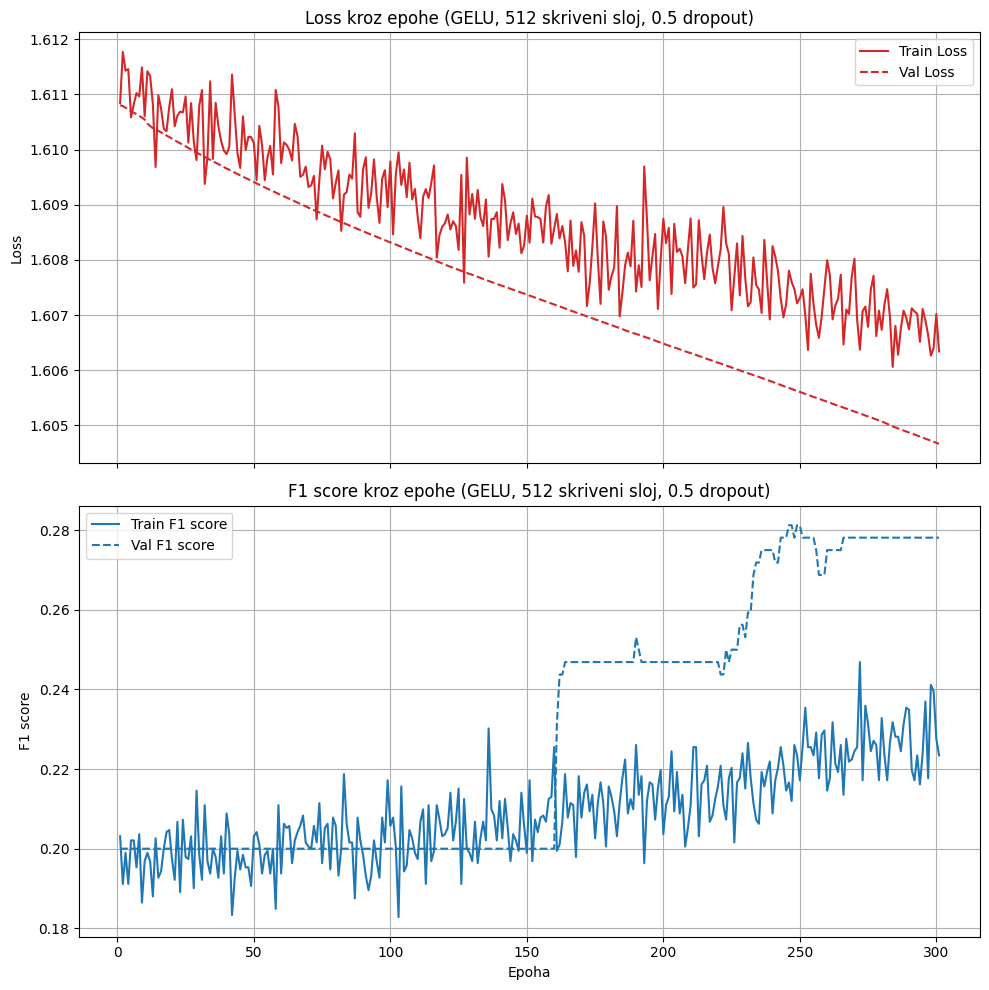

In [691]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(loss_list_train) + 1))

fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Prvi subplot – Loss
axs[0].plot(epochs, loss_list_train, label='Train Loss', color='tab:red', linestyle='-')
axs[0].plot(epochs, val_loss_list, label='Val Loss', color='tab:red', linestyle='--')
axs[0].set_ylabel('Loss')
axs[0].set_title(f'Loss kroz epohe (GELU, {hidden_dim} skriveni sloj, {dropout} dropout)')
axs[0].legend()
axs[0].grid(True)

# Drugi subplot – NDCG
axs[1].plot(epochs, f1_train, label='Train F1 score', color='tab:blue', linestyle='-')
axs[1].plot(epochs, f1_score_valid, label='Val F1 score', color='tab:blue', linestyle='--')
axs[1].set_xlabel('Epoha')
axs[1].set_ylabel('F1 score')
axs[1].set_title(f'F1 score kroz epohe (GELU, {hidden_dim} skriveni sloj, {dropout} dropout)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [692]:
fig.savefig(os.path.join(path, 'metrike.jpg'))

In [ ]:
from sklearn.metrics import f1_score
from sklearn.metrics import ndcg_score

model.eval()
test_loss = 0.0
all_preds_test = []
all_targets_test = []

with torch.no_grad():
    for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_test):
        cat_features = {k: v.to(device) for k, v in cat_features.items()}
        num_tensor = num_tensor.to(device)
        target = target.to(device)

        output = model(cat_features, num_tensor)  # [batch, 20, 5]
        loss = criterion(output.view(-1, 5), target.view(-1).long())
        test_loss += loss.item()

        preds = output.argmax(dim=2).cpu().numpy()
        targs = target.cpu().numpy()

        all_preds_test.extend(preds.flatten())
        all_targets_test.extend(targs.flatten())

test_f1 = f1_score(all_targets_test, all_preds_test, average='macro')
avg_test_loss = test_loss / len(loader_test)

print(f"Rezultati na test skupu:")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test F1-score: {test_f1:.4f}")



📊 Rezultati na test skupu:
Test Loss: 1.6052
Test F1-score: 0.1542


In [ ]:
# model.eval()
# with torch.no_grad():
#     # Uzmemo samo prvi batch — prva trka
#     cat_features, num_tensor, target, drivers_num, position_quali = next(iter(loader_val))

#     cat_features = {k: v.to(device) for k, v in cat_features.items()}
#     num_tensor = num_tensor.to(device)
#     target = target.to(device)

#     output = model(cat_features, num_tensor).squeeze(-1)
#     scores = output.cpu().numpy()[0]
#     true_ranks = target.cpu().numpy()[0]
#     quali_pos = position_quali.numpy()[0]
#     driver_ids = drivers_num.numpy()[0]

#     # Predviđeni poredak na osnovu najnižeg skora
#     pred_order = scores.argsort()  # indeks pozicija od najboljeg ka najgorem
#     print("\nPoređenje za jednu trku:\n")
#     print(f"{'Poz':<5}{'Vozač':<10}{'Stvarna':<10}{'Predviđena':<12}{'Kvalifikacije':<15}")
#     for pos, idx in enumerate(pred_order):
#         print(f"{pos+1:<5}{driver_ids[idx]:<10}{true_ranks[idx]:<10}{pos+1:<12}{quali_pos[idx]:<15}")



Poređenje za jednu trku:

Poz  Vozač     Stvarna   Predviđena  Kvalifikacije  


TypeError: unsupported format string passed to numpy.ndarray.__format__